Seojin

# Notice

You can visualize plot only in mac. I tested vedo in Ubuntu, but It did not work.

# Vedo(Visualization of эD Objects)

Vedo is scientific tool for visualizing 3d objects

Official site: https://vedo.embl.es  
Github: https://github.com/marcomusy/vedo/tree/master/examples/notebooks

# Mesh

For visualizing 3d Object, You should make mesh(vertexes) based on nifti image. For making vtk file, I used nii2mesh.

Github: https://github.com/neurolabusc/nii2mesh

ex) nii2mesh lt_hippo_fan.nii lt_hippo_fan_d.vtk

# Library

In [1]:
import nilearn.plotting
import nibabel as nb
import vedo
from scipy import optimize, stats
from matplotlib import colormaps, cm, colors
import matplotlib.pyplot as plt
import numpy as np
from os.path import join, expanduser

In [2]:
vedo.settings.default_backend='vtk'

# Custom function

custom function for converting coordinate system.


In [3]:
def LPSp_toRASp(xyz):
    """
    Convert LPS+ coordinate to RAS+ coordinate
    
    :param xyz: LPS+ coord(list)
    
    return xyz(list)
    """
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    
    return -x, -y, z

def RASp_toLPSp(xyz):
    """
    Convert RAS+ coordinate to LPS+ coordinate
    
    :param xyz: RAS+ coord(list)
    
    return xyz(list)
    """
    x = xyz[0]
    y = xyz[1]
    z = xyz[2]
    
    return -x, -y, z

def reference2imageCoord(xyz, affine):
    """
    change reference coordinate to image coordinate
    reference coordinate can be scanner coordinate or MNI coordinate...
    
    :param xyz: anatomical coordinate(np.array)
    :param affine: affine matrix(np.array)
    
    return image coordinate(np.array)
    """
    
    result = np.matmul(np.linalg.inv(affine), [xyz[0], xyz[1], xyz[2], 1])[0:3]
    result = np.ceil(result).astype(int) # note: This is ad-hoc process - (np.ceil)
    return result

# Paths

In [4]:
dir_path = "D:/Github/labs/GP"

# lt_putamen_nii_path = f"{dir_path}/putamen_caudateNucleus_left_HO.nii"
# rt_putamen_nii_path = f"{dir_path}/putamen_caudateNucleus_right_HO.nii"

lt_striatum_vtk_path = join(dir_path, 'scripts/KJH/GP_vis/putamen_caudateNucleus_left_HO.vtk')
rt_striatum_vtk_path = join(dir_path, 'scripts/KJH/GP_vis/putamen_caudateNucleus_right_HO.vtk')

# lt_putamen_nii_path = f"{dir_path}/mask.TTatlas.lh.caudate+putamen.resampled.binary.nii"
# rt_putamen_nii_path = f"{dir_path}/mask.TTatlas.rh.caudate+putamen.resampled.binary.nii"

# lt_putamen_vtk_path = f"{dir_path}/nii2mesh_mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"{dir_path}/nii2mesh_mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

# lt_putamen_vtk_path = f"{dir_path}/mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"{dir_path}/mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

## https://rordenlab.github.io/nii2meshWeb/
## Isolevel: custom 0.4, Post-smoothing: 496
# lt_putamen_vtk_path = f"/Users/clmn/Downloads/nii2mesh_mask.TTatlas.lh.caudate+putamen.resampled.binary.vtk"
# rt_putamen_vtk_path = f"/Users/clmn/Downloads/nii2mesh_mask.TTatlas.rh.caudate+putamen.resampled.binary.vtk"

# os.system(f"nii2mesh {lt_putamen_nii_path} -i b {lt_putamen_vtk_path}")
# os.system(f"nii2mesh {rt_putamen_nii_path} -i b {rt_putamen_vtk_path}")

striatum_vtk_volume_paths = [
    lt_striatum_vtk_path,
    rt_striatum_vtk_path
]

In [86]:
# Stat map
# stat_file_path = f"{dir_path}/r03-01.DLPFC_cTBS.n17.nii"
# stat_file_path = f"{dir_path}/Zstat.r03-01.M1_cTBS.n17.nii"
# stat_file_path = f"{dir_path}/Coef.DLPFC_cTBS-GA.nii"
# stat_file_path = f"{dir_path}/Coef.DLPFC_20Hz-GA.nii"
stat_file_path = join(dir_path, 'results/Zstat.DLPFC_cTBS_r03-r01-GA_r03-r01.nii')
# stat_file_path = f"{dir_path}/mask.TTatlas.ant.caudate+putamen.resampled.binary.nii"
stat = nb.load(stat_file_path)
print("stat-map shape:", stat.shape)
print(stat.affine)

t_stat_index = 0
t_stats = stat.get_fdata()[:,:,:,0, t_stat_index] # Select t-stat
# t_stats = stat.get_fdata()
t_stats.shape

stat-map shape: (77, 92, 77, 1, 2)
[[   2.5    -0.     -0.    -95.  ]
 [  -0.      2.5    -0.   -131.75]
 [   0.      0.      2.5   -77.  ]
 [   0.      0.      0.      1.  ]]


(77, 92, 77)

(array([9.16644056e-06, 1.99828404e-04, 1.89378662e-03, 1.12490559e-02,
        4.40777461e-02, 9.01721091e-02, 8.45990966e-01, 6.22951301e-03,
        1.74162371e-04, 3.66657622e-06, 0.00000000e+00]),
 array([-6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 <BarContainer object of 11 artists>)

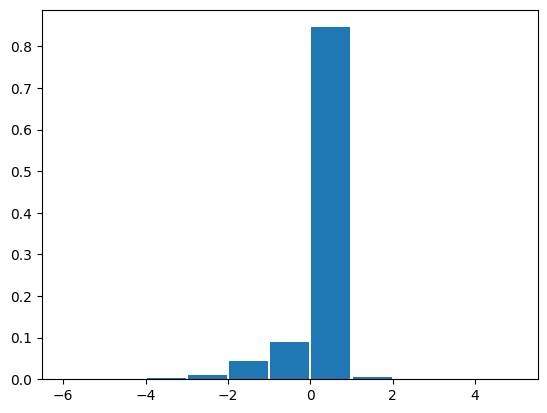

In [88]:
fig, ax = plt.subplots()
ax.hist(t_stats.flatten(), bins=np.arange(-6,6,1), align='mid', density=True, rwidth=0.95)

In [7]:
mask = nb.load(join(dir_path, 'results/mask.sum.caudate_4parts.separated_putamen.resampled.nii')).get_fdata()
mask.shape

(77, 92, 77)

# Visualize configuration


(0.0, 1.0)

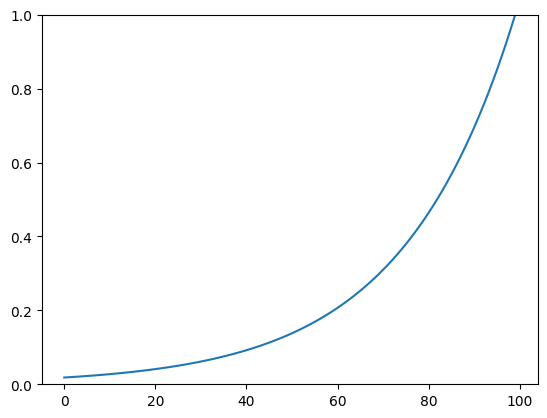

In [33]:
y = np.exp(2*np.linspace(-2, 0, 100))
plt.plot(y)
plt.ylim(0,1)

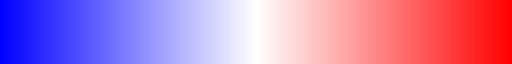

In [90]:
# cmap = colors.ListedColormap(
#     np.concatenate(
#         [
#             np.flip(cm.Blues(y), axis=0),
#             cm.Reds(y)
#         ],
#         axis=0
#     )
# )
cmap = cm.bwr
# cmap = cm.jet

cmap

In [92]:
p_thresh = 5.e-2
thresh = stats.norm.isf(0.5*p_thresh)
print(thresh)
## 최대 최소 설정
vmax = 3.5
vmin = -3.5
norm = colors.Normalize(vmin=vmin, vmax=vmax)

1.9599639845400545


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

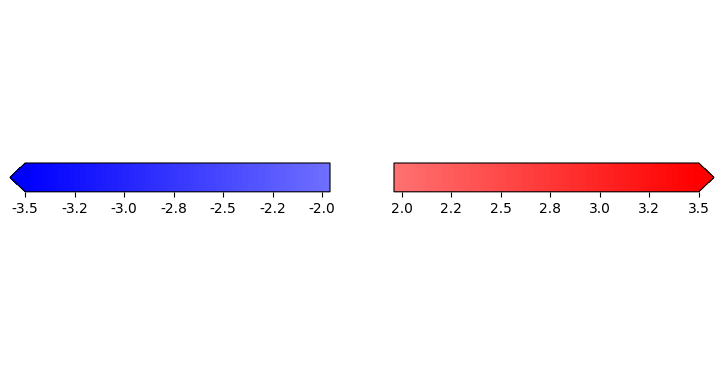

In [94]:
fig, ax = plt.subplots()

################
## upper cmap ##
################

### 컬러바 생성
array_cmap = cmap(range(cmap.N))[int(norm(thresh)*cmap.N):]
colormapping = cm.ScalarMappable(
    norm=colors.Normalize(vmin=thresh, vmax=vmax),
    cmap=colors.ListedColormap(array_cmap)
)

### 컬러바 삽입
# w = abs(vmax*0.1)
w = 0.5
cax = fig.add_axes([0.55, 0.5, w, 0.06])
cbar = fig.colorbar(
    colormapping, extend='max',
    orientation='horizontal',
    format='%.1f',
    cax=cax
)

################
## lower cmap ##
################

### 컬러바 생성
array_cmap = cmap(range(cmap.N))[:int(norm(-thresh)*cmap.N)]
colormapping = cm.ScalarMappable(
    norm=colors.Normalize(vmin=vmin, vmax=-thresh),
    cmap=colors.ListedColormap(array_cmap)
)
### 컬러바 삽입
# w = abs(vmin*0.1)
w = 0.5
cax = fig.add_axes([0.45-w, 0.5, w, 0.06])
cbar = fig.colorbar(
    colormapping, extend='min',
    orientation='horizontal',
    format='%.1f',
    cax=cax
)
ax.axis('off')

# Load Data

In [96]:
# Load Vertex files - (Before skipping next part, you need to identify coordinate about data. 
# In my case, they are RAS+ coordinate
# target_vtk_volumes - volume for visualizing stat
striatum_vtk_volumes = [vedo.load(vtk_path) for vtk_path in striatum_vtk_volume_paths]
# Merge target volumes
striatum_vtk_volume = vedo.merge(striatum_vtk_volumes)

In [98]:
# target = lt_striatum_vtk_path
target = rt_striatum_vtk_path
target_volume = vedo.load(target)

# target_volume = striatum_vtk_volume

In [100]:
t_stats[(t_stats>thresh)&(t_stats<-thresh)] = 0

# Merge target volumes

In [103]:
target_stats = []
for i, vertex in enumerate(target_volume.points()):
    RASp_coord = vertex
    image_coord = reference2imageCoord(RASp_coord, affine = stat.affine).astype(int)

    target_stats.append(t_stats[image_coord[0], image_coord[1], image_coord[2]])

In [105]:
# reverse y-axis
# target_vtk_volume = target_vtk_volume.clone(deep=False).mirror("y")

# Show


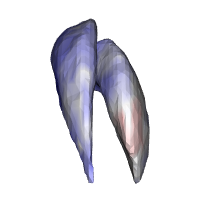

In [108]:
target_volume.cmap(cmap, target_stats, alpha=1.0, vmin=vmin, vmax=vmax)
target_volume.add_scalarbar(horizontal=True)

In [110]:
# Show
vedo.show(target_volume, axes=0, viewup='z', interactive=True, mode=0).close()
# vedo.show(target_vtk_volume, __doc__, viewup="z", axes=0).close()

# Mask volume

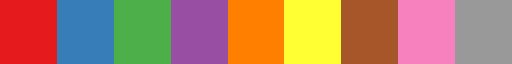

In [167]:
cmap = cm.Set1
cmap

In [169]:
mask_stats = []
for i, vertex in enumerate(target_volume.points()):
    RASp_coord = vertex
    image_coord = reference2imageCoord(RASp_coord, affine = stat.affine).astype(int)

    mask_stats.append(mask[image_coord[0], image_coord[1], image_coord[2]])


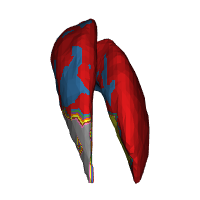

In [171]:
target_volume.cmap(cmap, mask_stats, alpha=1.0)
target_volume.add_scalarbar(horizontal=True)

In [174]:
vedo.show(target_volume, axes=0, viewup='z', interactive=True, mode=0).close()